<a href="https://colab.research.google.com/github/ever1318-cpu/Apartment_Defect_AI/blob/main/detail_part_full_data_train_eval_%EC%B5%9C%EC%A2%85%ED%95%99%EC%8A%B5%ED%8F%89%EA%B0%80_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 상세부위(전체 클래스 100%) 전체 데이터 최종 학습 · 평가 노트북

이 노트북은 **완전히 독립적으로 실행됩니다.** 다른 노트북을 먼저 실행해둘 필요 없이,
**DB 조회 → (필요시) S3에서 이미지 다운로드/Drive에 이미 받아둔 이미지 재사용 → 학습 → 평가**
까지 이 노트북 하나로 처음부터 끝까지 처리합니다. (예: 울산 다운1차 데이터처럼 이전에 이미
Drive에 받아두신 이미지가 있다면, 다운로드 셀은 자동으로 건너뛰고 바로 그 이미지로 학습합니다.)

**데이터 준비 단계 (1~6번 셀)**
1. Google Drive 마운트 + 공통 경로/설정 (`BK`, `DRIVE_IMG_DIR` 등 — 필요하면 이 경로만 실제
   위치에 맞게 수정)
2. DB 접속 정보 설정 (비밀번호는 필요할 때만 입력창으로 물어봄)
3. DB 조회 + 상세부위 클래스 확정 (Drive에 라벨 메타데이터가 이미 있으면 재조회 없이 재사용)
4. S3 → Drive 이미지 다운로드 — **이미 받아둔 파일은 즉시 건너뜀**, 중간에 끊겨도 다시 실행하면 이어받음
5. (선택, 권장) Drive → 런타임 로컬 디스크로 이미지 캐시 복사 (학습 속도 향상)
6. 위에서 준비된 이미지로 `splits`(train/validation/test) / `classes`(라벨 목록) / `Photos`
   (PyTorch Dataset) 구성 — 이후 모든 학습·평가 셀이 이 세 가지를 사용합니다.

**percls 단계별 노트북과의 차이점**
- 샘플링 단계(1000/3000/all) 없이 **처음부터 전체 클래스·전체 데이터**로 한 번만 학습합니다.
- `train_tf`, `eval_tf`, `EPOCHS`, `LR` 등 학습 설정을 이 노트북이 자체적으로 정의합니다(상세부위
  분류에 맞춘 증강·손실함수·스케줄 적용).
- 결과는 `OUTPUT_DIR/full_run/` 에 저장되며, 기존 `stages/percls_*` 폴더와는 완전히 분리되어 있어
  이전 실험 결과를 건드리지 않습니다.

**중간에 오류가 나거나 Colab 연결이 끊겨도 안전합니다**
- 이미지 다운로드(4번 셀)와 학습(11번 셀) 모두 일정 단위로 자동 중간 저장을 하고, 셀을 그대로
  다시 실행하면 멈춘 지점부터 이어집니다. 처음부터 새로 학습하려면 별도 안내에 따라 체크포인트를
  지워야 합니다.
- 손상되었거나 열리지 않는 이미지 파일이 섞여 있어도, 학습/평가/오분류 확인 셀 모두 해당 파일
  하나만 건너뛰고 계속 진행하도록 되어 있습니다(콘솔에 어떤 파일을 건너뛰었는지 출력됩니다).
- 즉, 어떤 셀이든 오류로 멈췄을 때는 원인을 확인한 뒤 **그 셀을 그대로 다시 실행**하면 됩니다.

셀 순서대로 실행하시면 됩니다.


## 1. Google Drive 마운트 + 공통 경로 설정

`BK`는 라벨 메타데이터·다운로드 진행상태·학습결과가 저장되는 Drive 폴더, `DRIVE_IMG_DIR`는
원본 이미지가 보관되는 Drive 폴더입니다. **울산 다운1차처럼 이전에 이미 받아둔 이미지가 있다면,
그 폴더 경로를 `DRIVE_IMG_DIR`에 맞게 바꿔주세요** — 그러면 3~4번 셀은 새로 받을 게 없어
금방 끝나고 바로 그 이미지로 학습이 진행됩니다.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "psycopg2-binary", "tqdm"], check=True)

import os, json, hashlib, re, glob, shutil, time, datetime, urllib.request, getpass, concurrent.futures
from collections import defaultdict, Counter
from pathlib import Path
from tqdm.auto import tqdm
import torch

# ── 공통 경로 (기존 작업과 동일한 위치를 기본값으로 씁니다. 다른 곳에 저장해두셨다면
#    이 두 경로만 실제 위치로 바꿔주세요) ──────────────────────────────────────
BK            = '/content/drive/MyDrive/하자상세부위_결과'      # Drive: 라벨/진행상태/학습결과
DRIVE_IMG_DIR = '/content/drive/MyDrive/ulsan_down1_images'    # Drive: 울산 다운1차 원본 이미지(기존에 받아두신 경로)
LOCAL_IMG_DIR = '/content/ds_detail_meta_local'                 # 런타임 로컬: 학습 속도용 캐시

USE_LOCAL_CACHE = True   # True 권장: Drive를 매 배치 네트워크로 읽는 것보다 훨씬 빠릅니다.

OUTPUT_DIR = Path(BK) / '학습결과_전체데이터'   # 체크포인트/평가결과 저장 위치 (Drive, 영구)
for p in [BK, DRIVE_IMG_DIR, str(OUTPUT_DIR)]:
    os.makedirs(p, exist_ok=True)

BATCH_SIZE = 96   # IMG_SIZE를 192로 줄인 만큼 배치 크기를 늘려 GPU 활용률/처리 속도를 높임 (OOM 나면 64로 되돌리세요)
PRETRAINED = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('\u2705 Drive 마운트 및 경로 준비 완료')
print(f'   BK            : {BK}')
print(f'   DRIVE_IMG_DIR : {DRIVE_IMG_DIR}')
print(f'   OUTPUT_DIR    : {OUTPUT_DIR}')
print(f'   device        : {device}')


Mounted at /content/drive
✅ Drive 마운트 및 경로 준비 완료
   BK            : /content/drive/MyDrive/하자상세부위_결과
   DRIVE_IMG_DIR : /content/drive/MyDrive/ulsan_down1_images
   OUTPUT_DIR    : /content/drive/MyDrive/하자상세부위_결과/학습결과_전체데이터
   device        : cuda


## 2. DB 접속 설정

**울산 다운지구 1차 입주자 사전점검 데이터만** 대상으로 하도록 `SITE_CODE = 'P0256D'`로 고정해
두었습니다(다른 단지를 섞고 싶으면 이 값만 `None`으로 바꾸세요). 이 조건으로 조회하면
"사진을 1장 이상 보유한 QUALITY 하자" 모집단이 약 6만 6천 건 수준으로 나오는 것으로 확인된
단지입니다 — 다만 이 노트북은 하자 건이 아니라 **사진 파일 단위**로 학습 데이터를 만들기 때문에,
아래 3번 셀에서 실제 조회되는 행 수(사진 수)는 이 모집단 건수와 다를 수 있습니다(하자 1건에
사진이 여러 장 달린 경우가 많기 때문입니다).

이미 `DRIVE_IMG_DIR`에 상세부위 폴더별로 이미지가 다 받아져 있다면, 다음 DB 조회·다운로드
셀들은 자동으로 할 일이 없다고 판단하고 빠르게 지나갑니다. 새로 조회해야 할 때만 아래에서 DB
비밀번호를 입력하는 창이 뜹니다.


In [2]:
DB_HOST = 'w-backupdb.c9u0e882q8zp.ap-northeast-2.rds.amazonaws.com'
DB_PORT = 5432
DB_NAME = 'BackupDB'
DB_USER = 'TruePostgres'
DB_PASS = ''   # 비워두면 실제로 DB 조회가 필요할 때만 아래에서 입력창이 뜹니다 (비밀번호를 코드에 남기지 않기 위함)

S3_REGION = 'ap-northeast-2'
S3_BUCKET = 'wmcsm-defect-file'

TYPES       = ['QUALITY']
TRAIN_MIN   = 150                     # 이 장수 미만인 상세부위는 '기타'로 통합
SPLIT_RATIO = (0.8, 0.1, 0.1)         # train : val : test (참고용 — 실제 배정은 해시 기반)
SEED        = 42
OTHER_LABEL = '기타(소수상세부위)'

# 울산 다운지구 1차 입주자 사전점검 데이터만 대상으로 합니다 (site_defect -> defect_site.code).
# 다른 단지를 포함한 전체로 넓히려면 None으로 바꾸세요.
SITE_CODE = 'P0256D'   # 울산 다운1차. 참고: 과천지식정보 = 'P0165D'
# SITE_CODE = None      # 전체 단지 대상으로 확장하려면 이 줄로 교체

_site_tag = SITE_CODE or 'ALL'
META_PATH = f'{BK}/metadata_{_site_tag}.jsonl'   # SITE_CODE가 파일명에 포함되어, 대상 단지를 바꾸면 자동으로 새로 조회됩니다
TAX_PATH  = f'{BK}/taxonomy_{_site_tag}.json'
DL_PROGRESS_PATH = Path(f'{BK}/dl_progress_{_site_tag}.json')   # SITE_CODE별로 분리 — 다른 단지 다운로드 기록과 섞이지 않도록
IMG_INDEX_PATH   = Path(f'{BK}/drive_img_index_{_site_tag}.json')  # Drive 실제 파일 목록 캐시(파일명 기준) — 한 번 만들면 재사용
BATCH_SAVE = 300   # 이 개수마다 다운로드 진행상태를 Drive에 저장

print('\u2705 DB/다운로드 설정 완료')


✅ DB/다운로드 설정 완료


## 3. DB 조회 + 상세부위 클래스 확정

이미 만들어둔 라벨 파일(`metadata.jsonl`)이 Drive에 있으면 DB를 다시 조회하지 않고 그걸 그대로
불러옵니다. 없을 때만 실제로 DB에 접속해서 상세부위 라벨을 만듭니다. `TRAIN_MIN`장 미만인
상세부위는 `기타(소수상세부위)`로 합쳐지고, `BEFORE`(하자 접수 시점) 사진만 학습 대상이 되며,
사진은 하자 ID의 해시값으로 train/val/test 8:1:1로 나뉩니다.


In [3]:
import psycopg2


def norm_phase(v):
    u = (v or '').upper()
    if 'BEFORE' in u: return 'BEFORE'
    if 'AFTER'  in u: return 'AFTER'
    if 'DONE'   in u: return 'DONE'
    return u or 'ETC'


def assign_split(did):
    h = int(hashlib.md5(f'{SEED}_{did}'.encode()).hexdigest(), 16) % 1000
    if h < 800: return 'train'
    if h < 900: return 'val'
    return 'test'


def s3_url(path, bucket):
    if path.startswith('http'):
        return path
    b = bucket or S3_BUCKET
    key = path.split('/', 3)[3] if path.startswith('s3://') else path.lstrip('/')
    return f'https://{b}.s3.{S3_REGION}.amazonaws.com/{key}'


if os.path.exists(META_PATH) and os.path.exists(TAX_PATH):
    print(f'\u2705 Drive에서 라벨 메타데이터 로드: {META_PATH}')
    recs = [json.loads(l) for l in open(META_PATH, encoding='utf-8')]
    tax  = json.load(open(TAX_PATH, encoding='utf-8'))
else:
    if not DB_PASS:
        DB_PASS = getpass.getpass('\U0001f511 DB 비밀번호를 입력하세요: ')

    print('[1/4] DB 조회 중 (1~2분)...')
    SQL = """
    SELECT d.id                 AS defect_id,
           f.full_path          AS file_path,
           f.bucket_name        AS bucket,
           f.file_type          AS phase_raw,
           pd.name              AS detail,
           wk.name              AS gongjong,
           cz.name              AS cause,
           s.name               AS complex_name,
           s.site_code          AS complex,
           h.no_dong            AS dong,
           h.no_ho              AS ho,
           d.receipt_at         AS received_at
    FROM site_defect d
    JOIN site_defect_file f          ON f.defect_id = d.id
    JOIN site_site_defect_item i     ON i.id = d.site_defect_item_id
    JOIN site_site_part_detail_map m ON m.id = i.site_site_part_detail_map_id
    JOIN defect_part_detail pd       ON pd.id = m.part_detail_id
    LEFT JOIN defect_work_kind wk    ON wk.id = d.work_kind_id
    LEFT JOIN defect_cause cz        ON cz.id = d.cause_id
    JOIN defect_ho   h  ON h.id = d.ho_id
    JOIN defect_dong dg ON dg.id = h.dong_id
    JOIN defect_site s  ON s.id = dg.site_id
    WHERE d.is_deleted = false
      AND d.type = ANY(%(types)s)
      AND pd.name IS NOT NULL AND pd.name <> ''
      AND f.full_path IS NOT NULL
      AND (%(site_code)s IS NULL OR s.code = %(site_code)s)
    """
    conn = psycopg2.connect(host=DB_HOST, port=DB_PORT, dbname=DB_NAME,
                             user=DB_USER, password=DB_PASS, connect_timeout=10)
    cur = conn.cursor()
    cur.execute(SQL, {'types': TYPES, 'site_code': SITE_CODE})
    cols = [d[0] for d in cur.description]
    raw  = [dict(zip(cols, r)) for r in cur.fetchall()]
    conn.close()
    site_label = f'단지 코드 {SITE_CODE} (울산 다운1차)' if SITE_CODE else '전체 단지'
    print(f'  조회 완료 [{site_label}]: {len(raw):,}행 (사진 파일 단위, 하자 1건당 여러 장일 수 있음)')

    print('[2/4] 클래스 확정...')
    before_cnt = Counter()
    for r in raw:
        if norm_phase(r['phase_raw']) == 'BEFORE':
            before_cnt[r['detail']] += 1

    main_cls = sorted([d for d, n in before_cnt.items() if n >= TRAIN_MIN])
    cls_set  = set(main_cls)
    to_label = lambda d: d if d in cls_set else OTHER_LABEL
    labels   = main_cls + [OTHER_LABEL]
    lmap     = {name: i for i, name in enumerate(labels)}
    print(f'  정식 클래스: {len(main_cls)}종 + 기타 = {len(labels)}종')

    print('[3/4] metadata.jsonl 생성...')
    tmp_meta = '/content/metadata.jsonl'
    n_tr = 0
    with open(tmp_meta, 'w', encoding='utf-8') as fp:
        for r in raw:
            phase        = norm_phase(r['phase_raw'])
            label        = to_label(r['detail'])
            is_trainable = (phase == 'BEFORE')
            split        = assign_split(r['defect_id']) if is_trainable else None
            fp.write(json.dumps({
                'image_id':    r['file_path'],
                's3_url':      s3_url(r['file_path'], r['bucket']),
                'file_path':   r['file_path'],
                'phase':       phase,
                'label_class': label,
                'label_id':    lmap[label],
                'is_trainable': is_trainable,
                'split':       split,
            }, ensure_ascii=False) + '\n')
            if is_trainable:
                n_tr += 1

    print('[4/4] taxonomy.json 생성 + Drive 저장...')
    tax = {
        'task': 'detail_classification',
        'train_min_threshold': TRAIN_MIN,
        'types': TYPES,
        'num_classes': len(labels),
        'label_map': lmap,
    }
    tmp_tax = '/content/taxonomy.json'
    json.dump(tax, open(tmp_tax, 'w', encoding='utf-8'), ensure_ascii=False, indent=2)
    shutil.copy(tmp_meta, META_PATH)
    shutil.copy(tmp_tax, TAX_PATH)
    print(f'\u2705 Drive 저장 완료 (학습 대상 BEFORE 사진 {n_tr:,}장, {len(labels)}클래스)')

    recs = [json.loads(l) for l in open(tmp_meta, encoding='utf-8')]

train_recs = [r for r in recs if r.get('is_trainable') and r.get('split')]
sp_dist = Counter(r['split'] for r in train_recs)
print(f'\n학습 대상: {len(train_recs):,}장  (split 분포: {dict(sp_dist)})')
print(f'클래스 수: {len(set(r["label_class"] for r in train_recs))}')


✅ Drive에서 라벨 메타데이터 로드: /content/drive/MyDrive/하자상세부위_결과/metadata_P0256D.jsonl

학습 대상: 65,978장  (split 분포: {'train': 52659, 'test': 6604, 'val': 6715})
클래스 수: 33


## 4. S3 → Drive 이미지 다운로드 (이어받기, 이미 받은 파일은 자동 스킵)

`DRIVE_IMG_DIR/{split}/{상세부위}/파일명` 구조로 저장합니다. **"이미 완료" 판단은 진행상태
파일(`dl_progress_*.json`)만 믿지 않고, Drive에 실제로 있는 파일을 파일명 기준으로 먼저
한 번 인덱싱해서 확인합니다** — 그래야 예전에 다른 스크립트로 받아뒀거나 폴더 구조가 조금 다르게
저장돼 있어도 "이미 있는데 또 받으려는" 문제가 생기지 않습니다. 그래도 정말 없는 파일만
새로 받고, 중간에 끊겨도 이 셀을 그대로 다시 실행하면 이어받습니다.

**속도 관련 주의**: Google Drive는 FUSE로 마운트되어 있어서 파일 하나하나에 대해
`존재 확인(isfile)/크기 확인(getsize)`을 반복하면 파일 수만큼 네트워크 왕복이 발생해 수만
장 규모에서는 매우 느려지고(심하면 몇 시간, 사실상 멈춘 것처럼 보임) 시간초과가 날 수
있습니다. 그래서 이 셀은 **폴더 단위로 한 번만 훑는 방식(`os.walk`)**으로 인덱싱하고, 그
결과를 `drive_img_index_*.json`에 캐시해둡니다 — 처음 한 번만 시간이 걸리고, 이후로는 이
셀을 다시 실행해도(중간에 끊겨서 재실행하는 경우 포함) 캐시를 그대로 읽어서 몇 초 안에
끝납니다. Drive에 파일을 수동으로 추가/정리해서 캐시를 강제로 새로 만들고 싶으면
`FORCE_REINDEX = True`로 바꾸고 실행하세요.


In [4]:
def load_dl_progress():
    if DL_PROGRESS_PATH.exists():
        try:
            p = json.loads(DL_PROGRESS_PATH.read_text())
            print(f'\u2705 이전 다운로드 진행 로드: 완료 {p["done"]:,}  실패 {p["failed"]:,}')
            return p
        except Exception as e:
            print(f'\u26a0\ufe0f 진행 파일 손상({e}) -> 처음부터')
    return {'done': 0, 'failed': 0, 'done_ids': [], 'failed_ids': []}


def save_dl_progress(p):
    p['ts'] = datetime.datetime.now().isoformat()
    DL_PROGRESS_PATH.write_text(json.dumps(p, ensure_ascii=False, indent=2))


safe = lambda s: re.sub(r'[\\/:*?"<>|]+', '_', str(s).strip())


def dl_file(url, dst, retries=3):
    if os.path.exists(dst) and os.path.getsize(dst) > 0:
        return True
    for attempt in range(1, retries + 1):
        try:
            urllib.request.urlretrieve(url, dst)
            if os.path.exists(dst) and os.path.getsize(dst) > 0:
                return True
        except Exception:
            if attempt < retries:
                time.sleep(attempt)
    return False


FORCE_REINDEX = False   # True로 바꾸면 캐시를 무시하고 Drive를 처음부터 다시 훑습니다

def build_drive_index(root):
    """os.walk는 폴더당 한 번만 디렉터리를 읽고(각 파일마다 별도로 존재/크기를
    확인하지 않음), 그래서 Drive(FUSE) 위에서도 파일 개별 stat을 반복하는 것보다
    훨씬 빠릅니다. 진행 상황을 주기적으로 출력해 멈춘 것처럼 보이지 않게 합니다."""
    index = {}
    dir_n = file_n = 0
    t0 = time.time()
    for dirpath, _dirnames, filenames in os.walk(root):
        dir_n += 1
        for fn in filenames:
            index.setdefault(fn, os.path.join(dirpath, fn))
            file_n += 1
        if dir_n % 200 == 0:
            print(f'  ...폴더 {dir_n:,}개 / 파일 {file_n:,}개 확인 중 ({time.time() - t0:.0f}초 경과)')
    print(f'  Drive 스캔 완료: 폴더 {dir_n:,}개 / 파일 {file_n:,}개 ({time.time() - t0:.0f}초 소요)')
    return index


# ── 진행상태 파일(dl_progress_*.json)의 done 기록만 믿으면, 예전에 다른 범위(예: 다른
#    단지 포함 전체)로 실행했을 때 기록과 섞여서 "완료 수"가 실제와 안 맞을 수 있습니다.
#    그래서 Drive에 실제로 있는 파일을 파일명 기준으로 먼저 훑어서(폴더 구조가 정확히
#    {split}/{label}/파일명이 아니어도) "이미 받아둔 파일"을 다시 확인합니다.
#    단, 파일 하나하나를 확인(stat)하면 수만 장 규모에서 매우 느리므로(Drive FUSE),
#    폴더 단위로 한 번만 훑고(os.walk) 그 결과를 캐시해서 재사용합니다.
if IMG_INDEX_PATH.exists() and not FORCE_REINDEX:
    print(f'Drive 파일 인덱스 캐시 로드 중... ({IMG_INDEX_PATH.name})')
    existing_by_name = json.loads(IMG_INDEX_PATH.read_text())
    print(f'  캐시에서 확인된 파일: {len(existing_by_name):,}개 (다시 스캔하려면 FORCE_REINDEX=True)')
else:
    print('Drive에 이미 받아둔 파일 확인 중 (폴더 단위 스캔, 처음 한 번만 시간이 걸립니다)...')
    existing_by_name = build_drive_index(DRIVE_IMG_DIR)
    IMG_INDEX_PATH.write_text(json.dumps(existing_by_name, ensure_ascii=False))
    print(f'  인덱스를 캐시에 저장했습니다: {IMG_INDEX_PATH.name} (다음부터는 이 캐시를 바로 읽어옵니다)')

prog     = load_dl_progress()
done_set = set(str(x) for x in prog['done_ids'])
fail_set = set(str(x) for x in prog['failed_ids'])

seen_paths, deduped = {}, []
for r in train_recs:
    iid = r['image_id']
    if iid not in seen_paths:
        seen_paths[iid] = True
        deduped.append(r)

total = len(deduped)

# 파일명 인덱스에 이미 있는데 진행상태 파일엔 없던 항목을 '완료'로 다시 인식시킴
newly_recognized = 0
for r in deduped:
    iid = str(r['image_id'])
    if iid in done_set:
        continue
    fn = os.path.basename(r['file_path'].split('?')[0])
    if fn in existing_by_name:
        done_set.add(iid)
        prog['done_ids'].append(iid)
        newly_recognized += 1
if newly_recognized:
    prog['done'] = len(set(prog['done_ids']))
    print(f'  Drive에 이미 있던 파일 {newly_recognized:,}개를 다운로드 완료로 재인식했습니다.')

relevant_done = sum(1 for r in deduped if str(r['image_id']) in done_set)
print(f'전체 {total:,}장 (중복 제거 후) | 이미 완료: {relevant_done:,}장 | 남은: {total - relevant_done:,}장')

batch_n = 0
pbar = tqdm(deduped, total=total, initial=relevant_done, desc='S3->Drive', unit='파일', dynamic_ncols=True)
for r in pbar:
    iid = str(r['image_id'])
    if iid in done_set:
        continue

    fn = os.path.basename(r['file_path'].split('?')[0])
    if fn in existing_by_name:
        ok = True
    else:
        od  = os.path.join(DRIVE_IMG_DIR, r['split'], safe(r['label_class']))
        os.makedirs(od, exist_ok=True)
        dst = os.path.join(od, fn)
        ok = dl_file(r['s3_url'], dst)
        if ok:
            existing_by_name[fn] = dst

    if ok:
        prog['done'] += 1; done_set.add(iid); prog['done_ids'].append(iid)
        if iid in fail_set:
            fail_set.discard(iid)
            prog['failed_ids'] = [x for x in prog['failed_ids'] if str(x) != iid]
            prog['failed'] = len(prog['failed_ids'])
    else:
        if iid not in fail_set:
            prog['failed'] += 1; fail_set.add(iid); prog['failed_ids'].append(iid)

    pbar.set_postfix(done=prog['done'], fail=prog['failed'], refresh=False)
    batch_n += 1
    if batch_n % BATCH_SAVE == 0:
        save_dl_progress(prog)
        IMG_INDEX_PATH.write_text(json.dumps(existing_by_name, ensure_ascii=False))
pbar.close()
save_dl_progress(prog)
IMG_INDEX_PATH.write_text(json.dumps(existing_by_name, ensure_ascii=False))   # 새로 받은 파일까지 캐시에 반영 -> 다음 실행은 다시 스캔하지 않음

# ── 다음 셀(5, 6번)이 쓸 '레코드별 실제 파일 경로' 목록을 여기서 확정합니다.
#    폴더 구조가 {split}/{label}/파일명이 아니어도(예: 예전에 다른 방식으로 받아둔
#    파일들) existing_by_name(파일명 기준 인덱스)에 있는 실제 경로를 그대로 쓰기 때문에
#    다음 셀들이 다시 폴더를 스캔하며 구조를 가정할 필요가 없습니다.
RESOLVED_RECORDS = []
for r in deduped:
    iid = str(r['image_id'])
    if iid not in done_set:
        continue
    fn = os.path.basename(r['file_path'].split('?')[0])
    src = existing_by_name.get(fn)
    if not src:
        continue   # 이론상 없어야 하지만, 있다면 아래 요약의 '완료' 수와 차이로 드러남
    RESOLVED_RECORDS.append({
        'image_id': iid, 'image_path': src,
        'label_class': r['label_class'], 'split': r['split'],
    })

print('\n다운로드 결과:')
split_done = Counter(r['split'] for r in RESOLVED_RECORDS)
for sp in ['train', 'val', 'test']:
    n = split_done.get(sp, 0)
    mark = '\u2705' if n > 0 else '\u26a0\ufe0f'
    print(f'  {mark} {sp:5s}: {n:>7,}장 완료 (실제 파일 경로 확인됨)')
print(f'  실제 학습에 쓸 총 이미지: {len(RESOLVED_RECORDS):,}장 (다운로드 완료 표시 {len(done_set):,}장 중)')
if prog['failed'] > 0:
    print(f'\n\u26a0\ufe0f 실패 {prog["failed"]}건 — 이 셀을 다시 실행하면 자동 재시도됩니다.')


Drive 파일 인덱스 캐시 로드 중... (drive_img_index_P0256D.json)
  캐시에서 확인된 파일: 64,911개 (다시 스캔하려면 FORCE_REINDEX=True)
✅ 이전 다운로드 진행 로드: 완료 65,978  실패 0
전체 65,978장 (중복 제거 후) | 이미 완료: 65,978장 | 남은: 0장


S3->Drive: 100%|##########| 65978/65978 [00:00<?, ?파일/s]


다운로드 결과:
  ✅ train:  51,829장 완료 (실제 파일 경로 확인됨)
  ✅ val  :   6,606장 완료 (실제 파일 경로 확인됨)
  ✅ test :   6,476장 완료 (실제 파일 경로 확인됨)
  실제 학습에 쓸 총 이미지: 64,911장 (다운로드 완료 표시 65,978장 중)


## 5. (선택, 권장) 로컬 캐시로 복사 — 학습 속도 향상

Google Drive는 매 배치마다 네트워크로 파일을 읽어오기 때문에 학습 중 이미지 로딩이 느려질 수
있습니다. `USE_LOCAL_CACHE = True`(기본값)면 Drive의 이미지를 Colab 런타임 로컬 디스크로 한 번
복사해두고, 이후 모든 학습/평가는 이 로컬 사본을 사용합니다(런타임이 재시작되면 다시 복사—
Drive 원본은 그대로 남아있으니 안전합니다).

**폴더 구조를 다시 가정하지 않습니다**: 4번 셀에서 이미 레코드별로 실제 파일 경로를 확인해둔
`RESOLVED_RECORDS`를 그대로 사용해서 복사합니다. 그래서 기존에 받아둔 이미지가
`{split}/{상세부위}` 폴더 구조가 아니어도(예: 전부 한 폴더에 있거나 다른 구조로 저장돼 있어도)
문제없이 복사됩니다 — 4번 셀 로그에서 "완료"로 인식된 파일 수만큼 정확히 복사됩니다.

**속도**: Drive에서 파일 1개를 복사하는 데 걸리는 시간은 대부분 네트워크 지연(약 1초/파일)이라
한 번에 하나씩 복사하면 수만 장 기준 수십 시간이 걸릴 수 있습니다. 그래서 이 셀은
`CACHE_COPY_WORKERS`(기본 32)개를 **동시에** 복사해서 이 시간을 크게 줄입니다. 그래도 느리면
`CACHE_COPY_WORKERS` 값을 키워보시고(예: 48~64), 반대로 오류가 많이 나면 줄여보세요.


In [6]:
if 'USE_LOCAL_CACHE' not in globals():
    raise RuntimeError(
        'USE_LOCAL_CACHE가 정의되어 있지 않습니다. Colab 런타임이 재시작되면(오래 걸린 '
        '다운로드 도중 연결이 끊기는 경우 등) 이전에 실행했던 셀의 변수가 모두 사라집니다. '
        '이 셀만 다시 실행하지 말고, 1번 셀부터 순서대로(또는 상단 메뉴의 "런타임 -> 모두 '
        '실행") 다시 실행해주세요 — 이미 받아둔 이미지와 진행상태는 Drive에 저장되어 있으므로 '
        '금방 이어서 진행됩니다.'
    )
if 'RESOLVED_RECORDS' not in globals():
    raise RuntimeError(
        'RESOLVED_RECORDS가 정의되어 있지 않습니다. 4번 셀(S3->Drive 다운로드)을 먼저 '
        '실행해주세요. 런타임이 재시작됐다면 이 셀만 다시 실행하지 말고 1번 셀부터 다시 '
        '실행해주세요.'
    )

CACHE_COPY_WORKERS = 32   # Drive FUSE는 파일 1개당 ~1초의 네트워크 지연이 대부분이라(CPU 작업이
                          # 아니라) 동시에 여러 개를 복사하면 훨씬 빨라집니다. 오류가 잦으면 줄이세요.

def _copy_one_to_cache(r):
    try:
        src_path = r['image_path']
        if not os.path.exists(src_path):
            return ('missing', r, None)
        dst_dir = os.path.join(LOCAL_IMG_DIR, r['split'], safe(r['label_class']))
        os.makedirs(dst_dir, exist_ok=True)
        dst_path = os.path.join(dst_dir, os.path.basename(src_path))
        if os.path.exists(dst_path) and os.path.getsize(dst_path) == os.path.getsize(src_path):
            return ('skipped', r, dst_path)
        shutil.copyfile(src_path, dst_path)   # copy2 대신 copyfile: 메타데이터 복사(추가 stat 호출) 생략 -> 더 빠름
        return ('copied', r, dst_path)
    except Exception:
        return ('failed', r, None)   # 이 파일만 건너뛰고 계속 진행 (전체 셀이 죽지 않도록)


if USE_LOCAL_CACHE:
    print(f'Drive -> 로컬 캐시 복사 중 (총 {len(RESOLVED_RECORDS):,}장, {CACHE_COPY_WORKERS}개 동시 작업, 이미 있는 파일은 건너뜁니다)...')
    copied = skipped = missing = failed = 0
    with concurrent.futures.ThreadPoolExecutor(max_workers=CACHE_COPY_WORKERS) as ex:
        futures = [ex.submit(_copy_one_to_cache, r) for r in RESOLVED_RECORDS]
        pbar = tqdm(concurrent.futures.as_completed(futures), total=len(futures),
                    desc='로컬 캐시 복사', unit='파일', dynamic_ncols=True)
        for fut in pbar:
            status, r, dst_path = fut.result()
            if status == 'missing':
                missing += 1
            elif status == 'failed':
                failed += 1
            else:
                if status == 'copied':
                    copied += 1
                else:
                    skipped += 1
                r['image_path'] = dst_path   # 이후 셀부터는 로컬 사본 경로를 사용
            pbar.set_postfix(copied=copied, skipped=skipped, missing=missing, failed=failed, refresh=False)
    IMG_DIR = LOCAL_IMG_DIR
    msg = f'새로 복사 {copied:,}장, 이미 있어서 건너뜀 {skipped:,}장'
    if missing:
        msg += f', 원본을 찾지 못함 {missing:,}장(4번 셀을 다시 확인해주세요)'
    if failed:
        msg += f', 복사 실패 {failed:,}장(이 셀을 다시 실행하면 재시도됩니다)'
    print(f'\u2705 로컬 캐시 준비 완료 ({msg})')
else:
    IMG_DIR = DRIVE_IMG_DIR
    print(f'Drive 이미지를 직접 사용합니다: {IMG_DIR} (총 {len(RESOLVED_RECORDS):,}장)')


Drive -> 로컬 캐시 복사 중 (총 64,911장, 32개 동시 작업, 이미 있는 파일은 건너뜁니다)...


로컬 캐시 복사:   0%|          | 0/64911 [00:00<?, ?파일/s]

✅ 로컬 캐시 준비 완료 (새로 복사 59,263장, 이미 있어서 건너뜀 5,648장)


## 6. 다운로드된 이미지로 `splits` / `classes` / `Photos` 구성

`IMG_DIR/{split}/{상세부위}/파일명` 폴더 구조를 그대로 스캔해서, 이후 모든 학습·평가 셀이 쓰는
`splits`(train/validation[/test] DataFrame), `classes`(라벨 이름 목록), `Photos`(PyTorch
Dataset)를 만듭니다. 이 셀부터는 완전히 이 노트북 안의 데이터만으로 동작합니다.


In [18]:
if 'RESOLVED_RECORDS' not in globals():
    raise RuntimeError(
        'RESOLVED_RECORDS가 정의되어 있지 않습니다. 4번 셀(S3->Drive 다운로드)과 5번 셀'
        '(로컬 캐시)을 먼저 실행해주세요. Colab 런타임이 재시작됐다면 이 셀만 다시 실행하지 '
        '말고 1번 셀부터 순서대로 다시 실행해주세요.'
    )

import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

SPLIT_NAME_MAP = {'train': 'train', 'val': 'validation', 'test': 'test'}

# 폴더 구조(예: {split}/{상세부위}/파일명)를 다시 스캔하지 않고, 4~5번 셀에서 이미
# 레코드별로 확인해둔 실제 파일 경로(RESOLVED_RECORDS)를 그대로 사용합니다. 예전에 다른
# 방식으로 받아둔 이미지가 폴더 구조가 달라도(예: split/label 폴더가 아니어도) 문제없이
# 인식되는 이유입니다.
rows, missing = [], 0
for r in RESOLVED_RECORDS:
    if not os.path.exists(r['image_path']):
        missing += 1
        continue
    rows.append({
        'image_path': r['image_path'],
        'label_class': r['label_class'],
        'split': SPLIT_NAME_MAP.get(r['split'], r['split']),
    })
if missing:
    print(f'\u26a0\ufe0f 실제 파일을 찾지 못해 제외된 항목: {missing:,}장')

all_df = pd.DataFrame(rows)
if len(all_df) == 0:
    raise RuntimeError(
        '학습에 쓸 이미지를 하나도 찾지 못했습니다. 4번 셀(S3->Drive 다운로드)이 끝까지 '
        '실행됐는지, DRIVE_IMG_DIR 경로가 실제 데이터 위치와 맞는지 확인해주세요.'
    )

classes = sorted(all_df['label_class'].unique().tolist())
label_to_id = {name: i for i, name in enumerate(classes)}
all_df['label'] = all_df['label_class'].map(label_to_id)

splits = {}
for split_key in ['train', 'validation', 'test']:
    part = all_df[all_df['split'] == split_key].reset_index(drop=True)
    if len(part) > 0:
        splits[split_key] = part[['image_path', 'label']]

print('클래스 수:', len(classes))
print('클래스 목록:', classes)
for k, v in splits.items():
    print(f'{k}: {len(v):,}장')


class Photos(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row['label'])


클래스 수: 33
클래스 목록: ['PL창', 'PL창틀(코킹)', '걸레받이', '걸레받이(대리석)', '기타(소수상세부위)', '도어록목문', '도장', '도장(외부)', '디딤판', '마블(목창호)', '목문', '몰딩', '문틀', '바탕면(견출)', '바탕면(내장)', '방화문', '방화문틀(도장)', '벽지', '붙박이장', '신발장', '씽크상부장', '씽크하부장', '아일랜드식탁장', '유리', '주방장식장', '준공청소', '천정지', '코킹', '코킹(유리)', '타일', '펜트리문', '펜트리문틀', '화장대']
train: 51,829장
validation: 6,606장
test: 6,476장


## 7. 그래프 한글 폰트 설정 (가장 먼저 1번만 실행)

이 노트북은 클래스별 F1 그래프, 혼동행렬, 전체 vs 미학습 비교 그래프 등에서 상세부위
이름(한글)을 축/제목에 그대로 사용합니다. Colab 기본 matplotlib은 한글 폰트가 없어서
그래프의 한글이 네모(□)로 깨져 보이는데, 이 셀을 맨 처음 한 번 실행해두면 이후의 모든
그래프 셀에서 한글이 정상적으로 표시됩니다. (런타임이 재시작되면 다시 한 번 실행해주세요.)


In [19]:
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


def setup_korean_font():
    # 1) 이미 설치되어 있는 한글 폰트가 있으면 그걸 사용 (재실행 시 빠르게 넘어감)
    installed = {f.name for f in fm.fontManager.ttflist}
    for candidate in ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic"]:
        if candidate in installed:
            plt.rcParams["font.family"] = candidate
            plt.rcParams["axes.unicode_minus"] = False
            print(f"한글 폰트 설정 완료: {candidate}")
            return

    # 2) 없으면 나눔고딕을 설치 (Colab/Linux 기준)
    try:
        subprocess.run(["apt-get", "-qq", "update"], check=True,
                        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=True,
                        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for font_path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = "NanumGothic"
        plt.rcParams["axes.unicode_minus"] = False
        print("나눔고딕 설치 및 폰트 설정 완료")
    except Exception as e:
        print(f"한글 폰트 자동 설치에 실패했습니다 ({e}).")
        print("그래프의 한글이 깨져 보일 수 있습니다 — 런타임 유형이 Linux(Colab 기본)가 맞는지 확인해주세요.")
        plt.rcParams["axes.unicode_minus"] = False


setup_korean_font()


한글 폰트 설정 완료: NanumGothic


## 8. 전체 클래스(100%) 라벨 재매핑 (제외 없음)

In [20]:
import pandas as pd

# ====== 1) 전체 클래스(100%) 유지하고 라벨만 0..N-1로 재매핑 ======
# (이전 버전은 누적 95% 커버리지 기준으로 소수 클래스 11개를 제외했으나,
#  이번에는 제외 없이 TRAIN_MIN 병합 이후의 모든 클래스를 그대로 사용합니다.)
all_labels = pd.concat([splits["train"]["label"], splits["validation"]["label"]])
class_counts = all_labels.value_counts().sort_values(ascending=False)
cum_ratio = class_counts.cumsum() / class_counts.sum()

top_classes = class_counts.index.tolist()   # 100% = 전체 클래스 포함 (제외 없음)

print("=== 클래스별 비중 (전체 클래스 100% 포함) ===")
for label, count in class_counts.items():
    pct = count / class_counts.sum() * 100
    print(f"   label {label}: {count:>6}장  ({pct:5.1f}%, 누적 {cum_ratio[label]*100:5.1f}%)")

covered_pct = class_counts.loc[top_classes].sum() / class_counts.sum() * 100
print(f"\n선택된 클래스 {len(top_classes)}개 (전체 {len(class_counts)}개 중), 누적 비중 {covered_pct:.1f}%")

old_to_new = {old: new for new, old in enumerate(top_classes)}
new_to_old = {v: k for k, v in old_to_new.items()}
NUM_CLASSES = len(top_classes)
print("\n원래 라벨 -> 새 라벨 매핑:", old_to_new)


def filter_and_remap(df):
    filtered = df[df["label"].isin(top_classes)].copy()
    filtered["label"] = filtered["label"].map(old_to_new).astype(int)
    return filtered.reset_index(drop=True)


splits = {k: filter_and_remap(v) for k, v in splits.items()}

for k, v in splits.items():
    print(f"필터링 후 {k}: {len(v)}장")

classes = [classes[new_to_old[i]] for i in range(NUM_CLASSES)]
print("\n새 클래스 목록(순서=새 라벨):", classes)


=== 클래스별 비중 (전체 클래스 100% 포함) ===
   label 17:  11245장  ( 19.2%, 누적  19.2%)
   label 6:   9855장  ( 16.9%, 누적  36.1%)
   label 27:   6318장  ( 10.8%, 누적  46.9%)
   label 29:   4628장  (  7.9%, 누적  54.8%)
   label 25:   3196장  (  5.5%, 누적  60.3%)
   label 16:   2902장  (  5.0%, 누적  65.3%)
   label 4:   2824장  (  4.8%, 누적  70.1%)
   label 0:   2585장  (  4.4%, 누적  74.5%)
   label 26:   1709장  (  2.9%, 누적  77.5%)
   label 9:   1658장  (  2.8%, 누적  80.3%)
   label 12:   1097장  (  1.9%, 누적  82.2%)
   label 28:   1060장  (  1.8%, 누적  84.0%)
   label 10:   1003장  (  1.7%, 누적  85.7%)
   label 19:    838장  (  1.4%, 누적  87.1%)
   label 31:    720장  (  1.2%, 누적  88.4%)
   label 7:    705장  (  1.2%, 누적  89.6%)
   label 21:    669장  (  1.1%, 누적  90.7%)
   label 8:    617장  (  1.1%, 누적  91.8%)
   label 15:    597장  (  1.0%, 누적  92.8%)
   label 32:    537장  (  0.9%, 누적  93.7%)
   label 18:    431장  (  0.7%, 누적  94.5%)
   label 22:    361장  (  0.6%, 누적  95.1%)
   label 20:    321장  (  0.5%, 누적  95.6%)
   labe

## 설정 + 상세부위 분류에 맞춘 데이터 증강

하자 상세부위(균열/누수/오염/들뜸 등) 사진은 **색과 질감**이 핵심 단서이기 때문에 증강을
너무 세게 걸면 오히려 판별에 필요한 신호가 사라집니다. 아래 값들은 그 점을 고려해 잡은
값이며, 필요하면 조정하세요.

- `RandomResizedCrop(scale=(0.75, 1.0))`: 촬영 거리/구도 차이에 강건해지되, 하한을 너무 낮추면
  결함 부위 자체가 잘려나갈 수 있어 0.75 이상으로 제한
- `ColorJitter`는 약하게만 (밝기/대비 ±15%, 채도 ±10%, 색상 ±2%) — 변색·오염 판별에 필요한 색 정보를 크게 훼손하지 않는 선
- 큰 회전은 넣지 않음 — 상세부위 사진은 보통 수직/수평이 유지된 상태로 촬영되므로, 과한 회전은
  비현실적인 샘플을 만들어 오히려 방해가 됨
- `RandomErasing`을 약하게 추가 — 반사광·그림자·다른 사물에 일부가 가려진 실제 촬영 조건에 대한 강건성


In [21]:
import torch
import torchvision.transforms as T

MODEL_NAME = "convnext_tiny"   # 더 큰 모델을 쓰려면 convnext_small / convnext_base 등으로 교체
IMG_SIZE = 192   # 224에서 축소 -> 픽셀 수(연산량) 약 27% 감소로 에폭당 시간 단축 (정확도 영향은 미미한 편)
EPOCHS = 30
EARLY_STOP_PATIENCE = 6
BASE_LR = 3e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 2
AMP_DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()   # 혼합정밀도 학습 (GPU에서 속도 향상)
SAVE_EVERY_N_IMAGES = 4000   # 이 정도 이미지를 처리할 때마다 에폭 중간에도 체크포인트 저장
                              # (너무 작으면 Drive 저장 때문에 느려지고, 너무 크면 끊겼을 때 손실이 커짐)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.02),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.08)),
])

eval_tf = T.Compose([
    T.Resize(int(IMG_SIZE * 1.14)),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print(f"모델: {MODEL_NAME} | 입력 크기: {IMG_SIZE} | EPOCHS: {EPOCHS} | 조기종료 patience: {EARLY_STOP_PATIENCE}")
print(f"혼합정밀도(AMP): {USE_AMP} ({AMP_DEVICE_TYPE})")


모델: convnext_tiny | 입력 크기: 192 | EPOCHS: 30 | 조기종료 patience: 6
혼합정밀도(AMP): True (cuda)


## 클래스 불균형 보정 (Effective Number 기반 Class-Balanced Loss)

단순히 `1/클래스당장수`로 가중치를 주면 표본이 극히 적은 클래스에 과도하게 가중치가 쏠려
오히려 학습이 불안정해질 수 있습니다. 여기서는 Cui et al. (CVPR 2019, *Class-Balanced Loss
Based on Effective Number of Samples*)에서 제안한 방식을 씁니다 — 표본이 늘어날수록
"실질적으로 늘어나는 정보량"이 체감한다고 보고(effective number), 그에 반비례하게 가중치를
주는 방식이라 단순 역빈도보다 완만하고 안정적입니다.


In [22]:
import numpy as np


def class_balanced_weights(labels, num_classes, beta=0.999):
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts = np.where(counts == 0, 1, counts)
    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32)


## 학습 (전체 클래스 · 전체 데이터, 단일 실행)

percls 단계별 실험과 마찬가지로 중단·재개, 조기 종료, 진행률 표시를 지원하며, 이번에는
**에폭 중간에 끊겨도** 이어받을 수 있도록 더 촘촘하게 저장합니다.

**오류/중단 시 재개 방식**
- 에폭이 끝날 때마다는 물론, 에폭 도중에도 `SAVE_EVERY_N_IMAGES`장 처리할 때마다
  `full_run/interrupted_last.pt`에 중간 상태(모델/옵티마이저/스케줄러 가중치 + 지금까지의
  loss 누적치 + 몇 번째 배치까지 처리했는지)를 저장합니다.
- 에폭마다 셔플 순서를 그 에폭 번호로 고정된 시드에서 만들기 때문에, 다시 실행하면 **정확히
  같은 순서**로 데이터를 다시 만들어서 중단된 배치 지점까지는 건너뛰고 그 다음부터 이어갑니다.
  (건너뛰는 구간도 이미지 로딩 자체는 일어나므로 완전히 공짜는 아니지만, 학습 계산과
  Drive 저장이 없는 만큼 처음부터 그 에폭을 다시 도는 것보다 훨씬 빠릅니다.)
- Colab 런타임 종류(에러, 연결 끊김, 수동 중단 등)에 상관없이 **이 셀을 그대로 다시 실행**하면
  자동으로 이어집니다. 위쪽 어떤 셀도 다시 실행할 필요 없습니다(이미 실행된 상태라면).
- 학습 중 이미지 파일이 깨져 있거나 손상되어 배치 하나를 통째로 못 읽는 경우, 그 배치만
  건너뛰고 학습을 계속합니다(전체가 죽지 않도록). 몇 개를 건너뛰었는지는 에폭이 끝날 때
  출력됩니다.

적용된 기법:
- Effective-Number 기반 Class-Balanced Loss + Label Smoothing(0.1)
- Warmup 2epoch 후 코사인 학습률 감쇠
- 혼합정밀도 학습(AMP, GPU 사용 시)
- 검증 macro F1 기준 best 체크포인트 저장 + 조기 종료(patience=6)


In [12]:
for _need in ('splits', 'classes', 'OUTPUT_DIR', 'Photos'):
    if _need not in globals():
        raise RuntimeError(
            f'{_need}이(가) 정의되어 있지 않습니다. Colab 런타임이 재시작되면 이전 셀의 변수가 '
            f'모두 사라지니, 이 셀만 다시 실행하지 말고 1번 셀부터 순서대로 다시 실행해주세요 '
            f'(이미 받아둔 이미지/진행상태는 Drive에 남아있어 금방 다시 이 지점까지 옵니다).'
        )

import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score

RUN_DIR = OUTPUT_DIR / "full_run"
RUN_DIR.mkdir(parents=True, exist_ok=True)
BEST_PATH = RUN_DIR / "best.pt"
INTERRUPT_PATH = RUN_DIR / "interrupted_last.pt"
HISTORY_PATH = RUN_DIR / "history.json"

train_df = splits["train"].reset_index(drop=True)
print("클래스별 학습 샘플 수:")
print(train_df["label"].value_counts().sort_index().to_string())

cb_weights = class_balanced_weights(train_df["label"].values, NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss(weight=cb_weights, label_smoothing=LABEL_SMOOTHING)


def make_train_loader(epoch_seed):
    # 에폭 번호로 셔플 시드를 고정 -> 중단 후 재개 시 똑같은 순서를 재현할 수 있어서
    # "몇 번째 배치까지 했는지"만 알면 정확히 그 지점부터 이어갈 수 있음
    g = torch.Generator()
    g.manual_seed(1000 + epoch_seed)
    return DataLoader(Photos(train_df, train_tf), batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, pin_memory=True, drop_last=True, generator=g)


val_loader = DataLoader(Photos(splits["validation"], eval_tf), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

save_every_n_batches = max(1, SAVE_EVERY_N_IMAGES // BATCH_SIZE)

model = timm.create_model(MODEL_NAME, pretrained=PRETRAINED, num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)


def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * min(progress, 1.0)))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def predict(eval_model, loader, tta=False):
    # 평가용 추론. 배치 하나가 손상된 이미지 때문에 실패해도 그 배치만 건너뛰고 계속 진행.
    eval_model.eval()
    actual, scores = [], []
    skipped = 0
    iterator = iter(loader)
    while True:
        try:
            images, labels = next(iterator)
        except StopIteration:
            break
        except Exception as e:
            skipped += 1
            print(f"  [경고] 평가 중 배치 로딩 실패로 건너뜀: {e}")
            continue
        images = images.to(device)
        actual.extend(labels.tolist())
        with torch.no_grad():
            with torch.autocast(device_type=AMP_DEVICE_TYPE, enabled=USE_AMP):
                logits = eval_model(images).softmax(1)
                if tta:
                    flipped = eval_model(torch.flip(images, dims=[3])).softmax(1)
                    logits = (logits + flipped) / 2
        scores.append(logits.float().cpu().numpy())
    if skipped:
        print(f"  총 {skipped}개 배치를 오류로 건너뛰었습니다(이미지 파일 손상 가능성).")
    return np.asarray(actual), np.concatenate(scores)


start_epoch = 1
start_batch = 0
resume_loss_total, resume_n = 0.0, 0
best_f1 = -1.0
epochs_since_improve = 0
history = []

if INTERRUPT_PATH.exists():
    ckpt = torch.load(INTERRUPT_PATH, map_location=device, weights_only=False)
    _resume_ok = True
    try:
        model.load_state_dict(ckpt["model_state"])
    except RuntimeError:
        # 클래스 수(NUM_CLASSES)가 이전 실행과 달라져 분류층 크기가 안 맞는 경우.
        # (백본 레이어는 이름/크기가 같으면 load_state_dict가 실패 전에 이미 이어받은 상태라
        #  분류층만 새로 초기화된 채로 처음부터 학습을 시작해도 전이학습 효과는 대부분 유지됩니다.)
        _resume_ok = False
        import shutil as _shutil, datetime as _dt
        backup_dir = OUTPUT_DIR / f"full_run_backup_{_dt.datetime.now().strftime('%Y%m%d_%H%M%S')}"
        backup_dir.mkdir(parents=True, exist_ok=True)
        for _f in [INTERRUPT_PATH, BEST_PATH, HISTORY_PATH]:
            if _f.exists():
                _shutil.move(str(_f), str(backup_dir / _f.name))
        print("\u26a0\ufe0f 클래스 구성이 이전 실행과 달라서(분류층 크기 불일치) 기존 체크포인트를 그대로 "
              "이어받을 수 없습니다. 백본 가중치는 최대한 이어받고, 분류층만 새로 초기화해서 처음부터 "
              "학습을 시작합니다.")
        print(f"   이전(다른 클래스 구성) 결과는 '{backup_dir}'로 옮겨두었으니 필요하면 나중에 확인하세요.")

    if _resume_ok:
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        if USE_AMP and ckpt.get("scaler_state"):
            scaler.load_state_dict(ckpt["scaler_state"])
        best_f1 = ckpt.get("best_f1", -1.0)
        epochs_since_improve = ckpt.get("epochs_since_improve", 0)
        history = ckpt.get("history", [])
        if ckpt.get("epoch_complete", True):
            start_epoch = ckpt["epoch"] + 1
            print(f"epoch {ckpt['epoch']}까지 완료된 상태에서 이어서 진행합니다 "
                  f"(epoch {start_epoch}부터, 정체 {epochs_since_improve}/{EARLY_STOP_PATIENCE}, best F1 {best_f1:.4f}).")
        else:
            start_epoch = ckpt["epoch"]
            start_batch = ckpt.get("batch_idx", 0)
            resume_loss_total = ckpt.get("partial_loss_total", 0.0)
            resume_n = ckpt.get("partial_n", 0)
            print(f"epoch {start_epoch} 진행 중 배치 {start_batch}에서 중단된 상태입니다 "
                  f"-> 같은 epoch, 같은 지점부터 이어서 진행합니다.")
    else:
        print(f"새로 학습을 시작합니다. (학습 샘플 {len(train_df)}장, 클래스 {NUM_CLASSES}개)")
else:
    print(f"새로 학습을 시작합니다. (학습 샘플 {len(train_df)}장, 클래스 {NUM_CLASSES}개)")

try:
    for epoch in range(start_epoch, EPOCHS + 1):
        model.train()
        loader = make_train_loader(epoch)
        n_batches = len(loader)

        if epoch == start_epoch and start_batch > 0:
            loss_total, n = resume_loss_total, resume_n
            resume_from = start_batch
        else:
            loss_total, n = 0.0, 0
            resume_from = 0

        target_n = len(train_df)
        n_seen = n
        next_report = ((n_seen * 10) // max(target_n, 1) + 1) * 10
        skipped_batches = 0

        iterator = iter(loader)
        batch_idx = 0
        while True:
            try:
                images, labels = next(iterator)
            except StopIteration:
                break
            except Exception as e:
                skipped_batches += 1
                print(f"  [경고] epoch {epoch} 배치 {batch_idx} 로딩 실패로 건너뜀: {e}")
                batch_idx += 1
                continue

            if batch_idx < resume_from:
                batch_idx += 1
                continue

            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=AMP_DEVICE_TYPE, enabled=USE_AMP):
                loss = loss_fn(model(images), labels)
            assert torch.isfinite(loss), "비정상 학습 손실"
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_total += loss.item() * len(labels)
            n += len(labels)
            n_seen += len(labels)

            progress_pct = n_seen / target_n * 100
            if progress_pct >= next_report or n_seen >= target_n:
                print(f"epoch {epoch:02d} 진행률 {min(progress_pct, 100):5.1f}%  "
                      f"({n_seen}/{target_n}장 학습됨)")
                while next_report <= progress_pct:
                    next_report += 10

            if (batch_idx + 1) % save_every_n_batches == 0:
                torch.save({
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "scheduler_state": scheduler.state_dict(),
                    "scaler_state": scaler.state_dict() if USE_AMP else None,
                    "epoch": epoch, "epoch_complete": False, "batch_idx": batch_idx + 1,
                    "partial_loss_total": loss_total, "partial_n": n,
                    "best_f1": best_f1, "epochs_since_improve": epochs_since_improve,
                    "history": history, "num_classes": NUM_CLASSES,
                }, INTERRUPT_PATH)
                print(f"  (중간 저장: epoch {epoch} 배치 {batch_idx + 1}/{n_batches})")

            batch_idx += 1

        if skipped_batches:
            print(f"  epoch {epoch}: 총 {skipped_batches}개 배치를 오류로 건너뛰었습니다.")

        scheduler.step()

        y_val, score_val = predict(model, val_loader)
        val_pred = score_val.argmax(1)
        val_f1 = f1_score(y_val, val_pred, labels=range(NUM_CLASSES), average="macro", zero_division=0)
        val_acc = accuracy_score(y_val, val_pred)
        train_loss = loss_total / max(n, 1)
        cur_lr = optimizer.param_groups[0]["lr"]
        history.append({"epoch": epoch, "train_loss": train_loss, "lr": cur_lr,
                         "val_macro_f1": float(val_f1), "val_accuracy": float(val_acc)})
        print(f"epoch {epoch:02d} 완료 | loss {train_loss:.4f} | lr {cur_lr:.2e} | "
              f"val F1 {val_f1:.4f} | val Acc {val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            epochs_since_improve = 0
            torch.save(model.state_dict(), BEST_PATH)
            print(f"  \u2191 새 최고 기록 갱신 (F1 {best_f1:.4f}) -> best.pt 저장")
        else:
            epochs_since_improve += 1

        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "scaler_state": scaler.state_dict() if USE_AMP else None,
            "epoch": epoch, "epoch_complete": True, "batch_idx": 0,
            "best_f1": best_f1, "epochs_since_improve": epochs_since_improve,
            "history": history, "num_classes": NUM_CLASSES,
        }, INTERRUPT_PATH)
        with open(HISTORY_PATH, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)

        # 다음 에폭부터는 재개 지점을 다시 쓰지 않음(이번 에폭에서만 유효)
        start_batch = 0
        resume_loss_total, resume_n = 0.0, 0

        if epochs_since_improve >= EARLY_STOP_PATIENCE:
            print(f"{EARLY_STOP_PATIENCE}epoch 연속 개선 없어 조기 종료합니다 "
                  f"(epoch {epoch}, best F1 {best_f1:.4f}).")
            break

except (KeyboardInterrupt, Exception):
    print(f"학습이 중단되었습니다. 직전 저장 지점은 {INTERRUPT_PATH} 에 있습니다. "
          f"이 셀을 그대로 다시 실행하면 중단된 지점(에폭 도중이었다면 그 배치)부터 이어집니다.")
    raise

print(f"\n학습 완료. best F1 = {best_f1:.4f}  ({BEST_PATH})")


클래스별 학습 샘플 수:
label
0     10005
1      8700
2      5571
3      4074
4      2838
5      2590
6      2522
7      2287
8      1539
9      1458
10      990
11      975
12      925
13      725
14      631
15      625
16      601
17      542
18      525
19      465
20      375
21      321
22      289
23      280
24      269
25      272
26      269
27      247
28      224
29      216
30      212
31      146
32      121


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

/tmp/ipykernel_1857/1556285105.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


⚠️ 클래스 구성이 이전 실행과 달라서(분류층 크기 불일치) 기존 체크포인트를 그대로 이어받을 수 없습니다. 백본 가중치는 최대한 이어받고, 분류층만 새로 초기화해서 처음부터 학습을 시작합니다.
   이전(다른 클래스 구성) 결과는 '/content/drive/MyDrive/하자상세부위_결과/학습결과_전체데이터/full_run_backup_20260929_052309'로 옮겨두었으니 필요하면 나중에 확인하세요.
새로 학습을 시작합니다. (학습 샘플 51829장, 클래스 33개)
  (중간 저장: epoch 1 배치 41/539)
epoch 01 진행률  10.0%  (5184/51829장 학습됨)
  (중간 저장: epoch 1 배치 82/539)
  [경고] epoch 1 배치 104 로딩 실패로 건너뜀: Caught OSError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_1857/3820714315.py", line 64, in __getitem__
    img = Image.open(row['image_path']).convert('RGB')
  File "/us

## 정확도 평가 루틴 (Accuracy / Top-K / F1 + 클래스별 리포트 + 혼동행렬)

`best.pt`(검증 macro F1 기준 최고 체크포인트)를 불러와 검증셋(및 `test` 스플릿이 있으면
테스트셋)에서 정밀 평가합니다. 평가 시에는 좌우반전 TTA(Test-Time Augmentation)를 적용해
측정치를 조금 더 안정적으로 만듭니다.



=== [검증셋] (n=6606) ===
Accuracy 0.7586 | Top-3 0.8513 | Macro F1 0.6461 | Weighted F1 0.7523
              precision    recall  f1-score   support

          벽지      0.832     0.904     0.867      1240
          도장      0.783     0.820     0.801      1155
          코킹      0.735     0.736     0.736       747
          타일      0.844     0.839     0.842       554
        준공청소      0.526     0.453     0.486       358
    방화문틀(도장)      0.880     0.846     0.863       312
  기타(소수상세부위)      0.678     0.536     0.599       302
         PL창      0.718     0.641     0.677       298
         천정지      0.645     0.588     0.615       170
     마블(목창호)      0.931     0.945     0.938       200
          문틀      0.607     0.636     0.621       107
      코킹(유리)      0.492     0.729     0.588        85
          목문      0.471     0.526     0.497        78
         신발장      0.845     0.770     0.806       113
       펜트리문틀      0.747     0.831     0.787        89
      도장(외부)      0.624     0.787     0.6

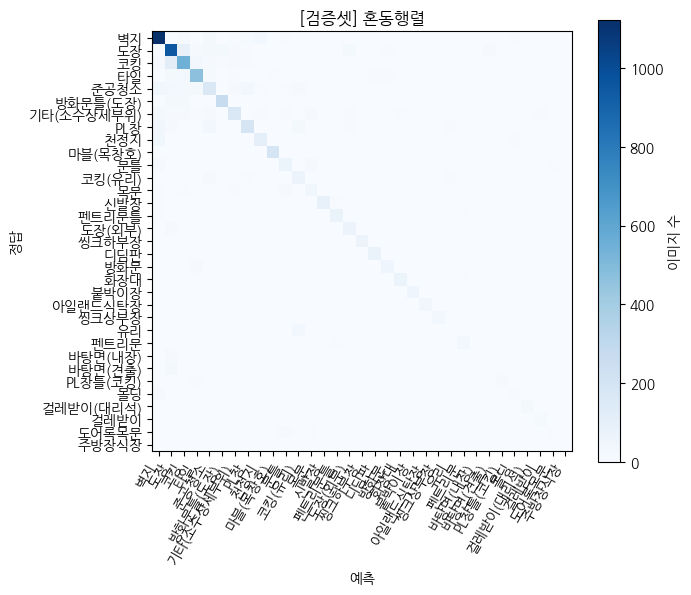


=== [테스트셋] (n=6476) ===
Accuracy 0.7532 | Top-3 0.8450 | Macro F1 0.6543 | Weighted F1 0.7472
              precision    recall  f1-score   support

          벽지      0.819     0.890     0.853      1232
          도장      0.810     0.824     0.817      1189
          코킹      0.722     0.787     0.753       662
          타일      0.787     0.797     0.792       482
        준공청소      0.497     0.399     0.443       363
    방화문틀(도장)      0.880     0.862     0.871       341
  기타(소수상세부위)      0.636     0.420     0.506       295
         PL창      0.750     0.690     0.719       313
         천정지      0.547     0.532     0.539       154
     마블(목창호)      0.862     0.980     0.917       147
          문틀      0.642     0.642     0.642       134
      코킹(유리)      0.669     0.739     0.702       115
          목문      0.554     0.583     0.568       115
         신발장      0.820     0.695     0.753       105
       펜트리문틀      0.804     0.848     0.825        92
      도장(외부)      0.609     0.838     0.

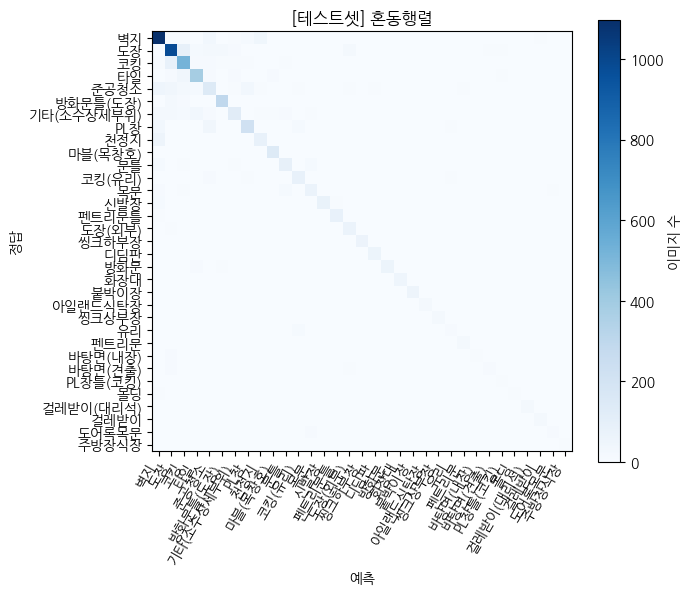


=== 요약 ===
split    n  accuracy  top3_accuracy  macro_f1  weighted_f1
  검증셋 6606  0.758553       0.851347  0.646102     0.752317
 테스트셋 6476  0.753243       0.844966  0.654263     0.747192


In [13]:
import numpy as np
import pandas as pd
import torch
import timm
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, f1_score, top_k_accuracy_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt

EVAL_MODEL_PATH = BEST_PATH   # 다른 체크포인트를 평가하려면 경로만 바꾸면 됩니다
USE_TTA = True
TOP_K = 3

eval_model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
eval_model.load_state_dict(torch.load(EVAL_MODEL_PATH, map_location=device, weights_only=True))


def evaluate_split(df, name):
    loader = DataLoader(Photos(df, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    y_true, y_score = predict(eval_model, loader, tta=USE_TTA)
    y_pred = y_score.argmax(1)
    k = min(TOP_K, NUM_CLASSES)

    acc = accuracy_score(y_true, y_pred)
    topk = top_k_accuracy_score(y_true, y_score, k=k, labels=list(range(NUM_CLASSES)))
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n=== [{name}] (n={len(y_true)}) ===")
    print(f"Accuracy {acc:.4f} | Top-{k} {topk:.4f} | Macro F1 {macro_f1:.4f} | Weighted F1 {weighted_f1:.4f}")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                                 target_names=classes, zero_division=0, digits=3))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES),
           xticklabels=classes, yticklabels=classes,
           xlabel="예측", ylabel="정답", title=f"[{name}] 혼동행렬")
    plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
    fig.colorbar(im, ax=ax, label="이미지 수")
    fig.tight_layout()
    plt.show()

    return ({"split": name, "n": len(y_true), "accuracy": acc, f"top{k}_accuracy": topk,
              "macro_f1": macro_f1, "weighted_f1": weighted_f1},
             y_true, y_pred, y_score)


val_summary, val_y, val_pred, val_score = evaluate_split(splits["validation"], "검증셋")
eval_results = [val_summary]

if "test" in splits:
    test_summary, test_y, test_pred, test_score = evaluate_split(splits["test"], "테스트셋")
    eval_results.append(test_summary)

result_df = pd.DataFrame(eval_results)
result_df.to_csv(OUTPUT_DIR / "full_run_eval_summary.csv", index=False, encoding="utf-8-sig")
print("\n=== 요약 ===")
print(result_df.to_string(index=False))


## 클래스(상세부위)별 F1 평가 + 그래프

Macro F1 같은 전체 평균 지표만 보면 "어떤 상세부위가 특히 약한지"가 가려집니다. 이 셀은
검증셋(및 `test` 스플릿이 있으면 테스트셋)에서 **상세부위 클래스 하나하나에 대해 Precision /
Recall / F1 / 샘플 수**를 표로 뽑고, F1이 낮은 순서대로 가로 막대그래프로 시각화합니다.
평균(Macro F1)보다 낮은 클래스는 빨간색, 높은 클래스는 초록색으로 표시되어 어떤 상세부위를
더 보강해야 하는지 한눈에 볼 수 있습니다. (EVAL_CODE 셀에서 이미 계산해 둔 `val_y`/`val_pred`
등을 그대로 재사용하므로 모델을 다시 돌리지 않습니다.)


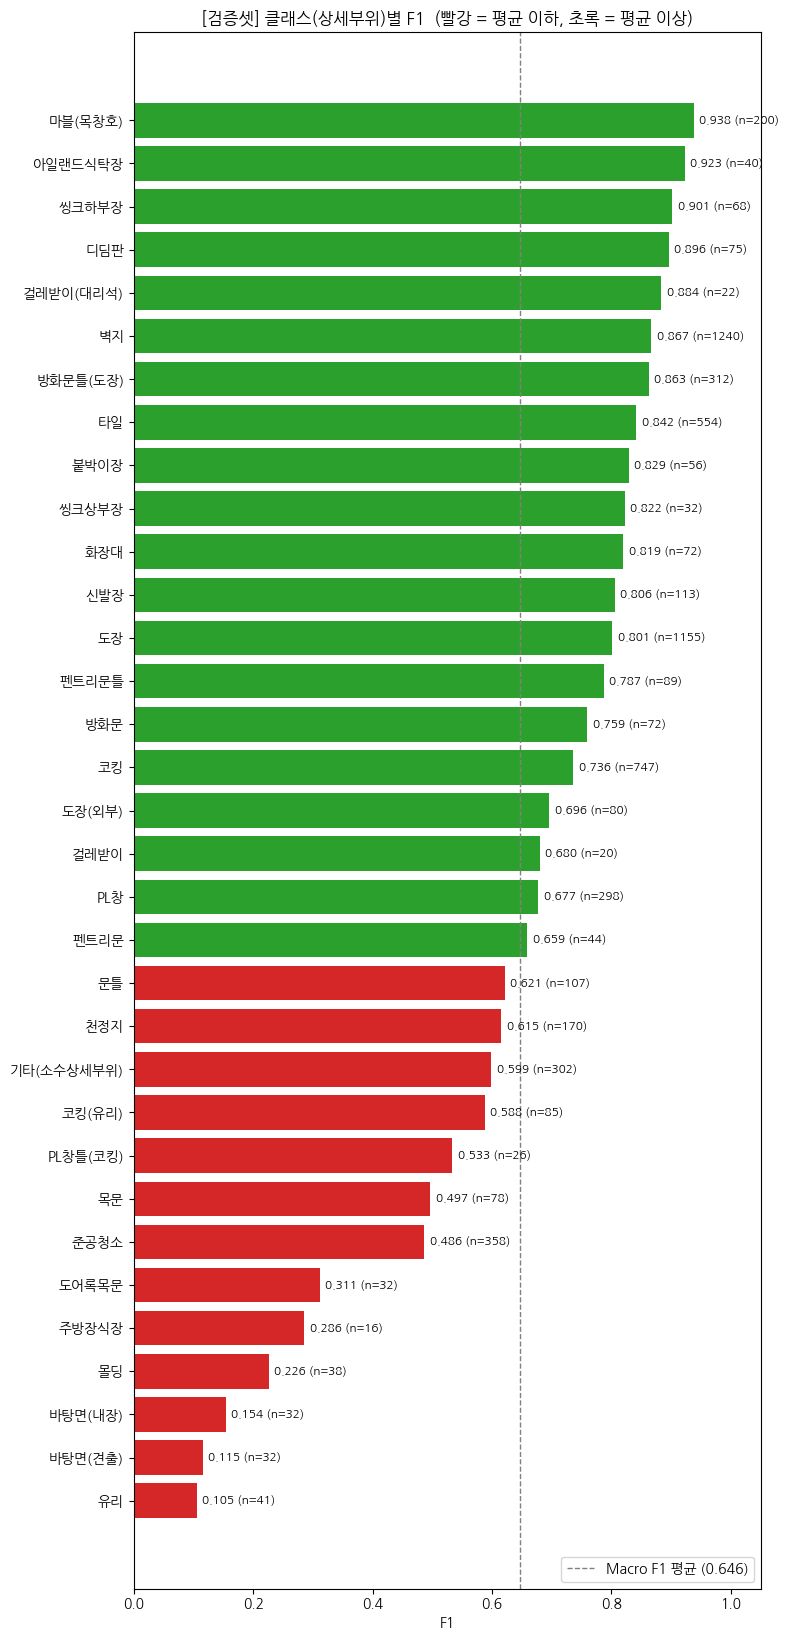

그래프 저장됨: /content/drive/MyDrive/하자상세부위_결과/학습결과_전체데이터/class_f1_val.png
표 저장됨: /content/drive/MyDrive/하자상세부위_결과/학습결과_전체데이터/class_f1_val.csv

[검증셋] F1이 가장 낮은 클래스 TOP 3 (보강이 필요할 가능성이 높은 상세부위):
  class  n_samples  precision   recall       f1
     유리         41     0.1875 0.073171 0.105263
바탕면(견출)         32     0.1500 0.093750 0.115385
바탕면(내장)         32     0.2000 0.125000 0.153846


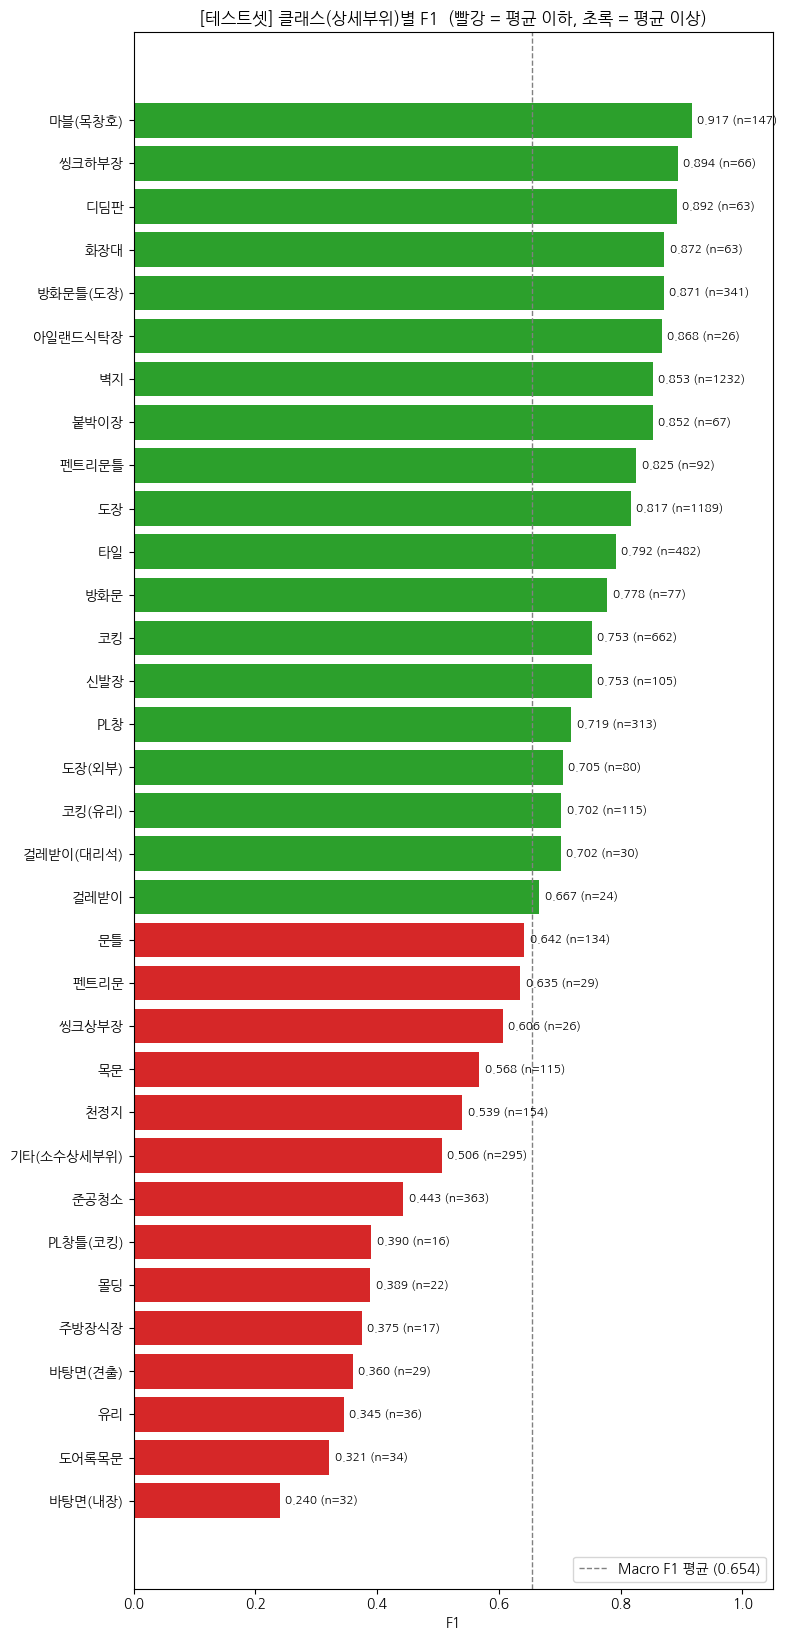

그래프 저장됨: /content/drive/MyDrive/하자상세부위_결과/학습결과_전체데이터/class_f1_test.png
표 저장됨: /content/drive/MyDrive/하자상세부위_결과/학습결과_전체데이터/class_f1_test.csv

[테스트셋] F1이 가장 낮은 클래스 TOP 3 (보강이 필요할 가능성이 높은 상세부위):
  class  n_samples  precision   recall       f1
바탕면(내장)         32   0.333333 0.187500 0.240000
  도어록목문         34   0.409091 0.264706 0.321429
     유리         36   0.454545 0.277778 0.344828


In [14]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def class_f1_table(y_true, y_pred, name):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0)
    df = pd.DataFrame({
        "class": classes,
        "n_samples": support,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }).sort_values("f1", ascending=True).reset_index(drop=True)

    macro_f1 = df["f1"].mean()

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(df))))
    colors = ["#d62728" if v < macro_f1 else "#2ca02c" for v in df["f1"]]
    bars = ax.barh(df["class"], df["f1"], color=colors)
    ax.axvline(macro_f1, color="gray", linestyle="--", linewidth=1,
               label=f"Macro F1 평균 ({macro_f1:.3f})")
    for bar, n in zip(bars, df["n_samples"]):
        ax.annotate(f"{bar.get_width():.3f} (n={int(n)})",
                    xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                    xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("F1")
    ax.set_title(f"[{name}] 클래스(상세부위)별 F1  (빨강 = 평균 이하, 초록 = 평균 이상)")
    ax.legend(loc="lower right")
    fig.tight_layout()

    safe_name = "val" if "검증" in name else ("test" if "테스트" in name else name)
    fig_path = OUTPUT_DIR / f"class_f1_{safe_name}.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"그래프 저장됨: {fig_path}")

    csv_path = OUTPUT_DIR / f"class_f1_{safe_name}.csv"
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"표 저장됨: {csv_path}")

    print(f"\n[{name}] F1이 가장 낮은 클래스 TOP 3 (보강이 필요할 가능성이 높은 상세부위):")
    print(df.head(3).to_string(index=False))

    return df


class_f1_val = class_f1_table(val_y, val_pred, "검증셋")

if "test" in splits:
    class_f1_test = class_f1_table(test_y, test_pred, "테스트셋")


## 전체 데이터셋 평가 vs 미학습 10% 평가 비교 (과적합 점검, 그래프)

같은 모델을 **① 전체 데이터셋(train+validation[+test], 즉 학습에 쓰인 데이터가 대부분 섞여있는
집합)** 과 **② 학습에 전혀 쓰이지 않은 순수 10%(가능하면 `test` 스플릿, 없으면 `validation`)**
에 각각 돌려서 비교합니다. ①이 ②보다 훨씬 높게 나온다면 모델이 학습 데이터를 "암기"했을
가능성이 있다는 신호이고, 둘이 비슷하다면 실제 새 사진에도 일반화가 잘 될 거라고 기대할 수
있습니다. `test` 스플릿은 학습 중 체크포인트 선택에도 전혀 관여하지 않은 완전한 미학습
데이터라 `validation`보다 더 엄격한 기준입니다(있으면 우선 사용).


  [경고] 평가 중 배치 로딩 실패로 건너뜀: Caught OSError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_1857/3820714315.py", line 64, in __getitem__
    img = Image.open(row['image_path']).convert('RGB')
  File "/usr/local/lib/python3.13/dist-packages/PIL/Image.py", line 986, in convert
    self.load()
    ~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/PIL/ImageFile.py", line 387, in load
    raise OSError(msg)
OSError: image file is truncated (44 bytes not processed)

  총 1개 배치를 오류로 건너뛰었습니다(이미지 파일 손상 가능성).
                            구분     n  accuracy  top3_accuracy  

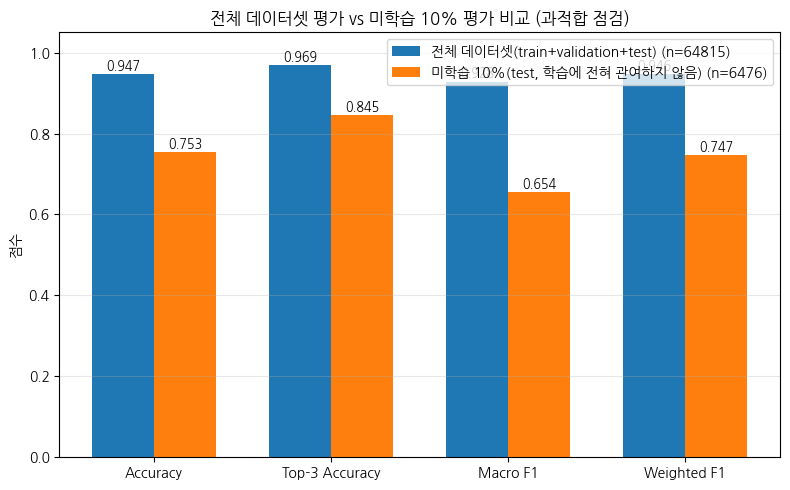


그래프 저장됨: /content/drive/MyDrive/하자상세부위_결과/학습결과_전체데이터/full_vs_holdout_comparison.png


In [15]:
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score
import matplotlib.pyplot as plt

TOP_K_CMP = min(TOP_K, NUM_CLASSES)

# 완전히 학습에 쓰이지 않은 10% : test가 있으면 test, 없으면 validation을 사용
if "test" in splits and len(splits["test"]) > 0:
    holdout_df = splits["test"]
    holdout_label = "미학습 10%(test, 학습에 전혀 관여하지 않음)"
else:
    holdout_df = splits["validation"]
    holdout_label = "미학습 10%(validation, 가중치 학습에는 사용되지 않음)"

full_data_df = pd.concat(
    [splits["train"], splits["validation"]] + ([splits["test"]] if "test" in splits else []),
    ignore_index=True,
)
full_label = "전체 데이터셋(train+validation" + ("+test" if "test" in splits else "") + ")"


def eval_metrics_on(df, name):
    loader = DataLoader(Photos(df, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    y_true, y_score = predict(eval_model, loader, tta=USE_TTA)
    y_pred = y_score.argmax(1)
    return {
        "구분": name,
        "n": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        f"top{TOP_K_CMP}_accuracy": top_k_accuracy_score(
            y_true, y_score, k=TOP_K_CMP, labels=list(range(NUM_CLASSES))),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


full_metrics = eval_metrics_on(full_data_df, full_label)
holdout_metrics = eval_metrics_on(holdout_df, holdout_label)

compare_df = pd.DataFrame([full_metrics, holdout_metrics])
print(compare_df.to_string(index=False))

gap = full_metrics["accuracy"] - holdout_metrics["accuracy"]
print()
if gap > 0.15:
    print(f"[주의] 전체 데이터셋 정확도와 미학습 10% 정확도 차이가 {gap:.3f}로 큽니다 -> 과적합 가능성이 있습니다.")
else:
    print(f"전체 데이터셋과 미학습 10% 정확도 차이 {gap:.3f} — 과적합 징후는 크지 않아 보입니다.")

# ---- 비교 그래프 ----
metric_keys = ["accuracy", f"top{TOP_K_CMP}_accuracy", "macro_f1", "weighted_f1"]
metric_labels = ["Accuracy", f"Top-{TOP_K_CMP} Accuracy", "Macro F1", "Weighted F1"]

x = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
full_vals = [full_metrics[m] for m in metric_keys]
holdout_vals = [holdout_metrics[m] for m in metric_keys]

bars1 = ax.bar(x - width / 2, full_vals, width, label=f"{full_label} (n={full_metrics['n']})")
bars2 = ax.bar(x + width / 2, holdout_vals, width, label=f"{holdout_label} (n={holdout_metrics['n']})")

for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", xy=(b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("점수")
ax.set_title("전체 데이터셋 평가 vs 미학습 10% 평가 비교 (과적합 점검)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

fig_path = OUTPUT_DIR / "full_vs_holdout_comparison.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"\n그래프 저장됨: {fig_path}")

compare_df.to_csv(OUTPUT_DIR / "full_vs_holdout_comparison.csv", index=False, encoding="utf-8-sig")


## 오분류 이미지 확인 (어떤 상세부위가 서로 헷갈리는지 시각적으로 진단)

숫자 지표만으로는 "왜 틀렸는지" 알기 어렵습니다. 검증셋에서 실제로 틀린 사진 몇 장을
정답/예측 라벨과 함께 직접 보면서, 상세부위 분류에 실질적으로 도움이 되는 개선점
(예: 특정 두 부위가 시각적으로 유사해서 혼동되는지, 사진 구도 문제인지)을 파악할 수 있습니다.


검증셋 오분류: 1595 / 6606장 (24.1%)


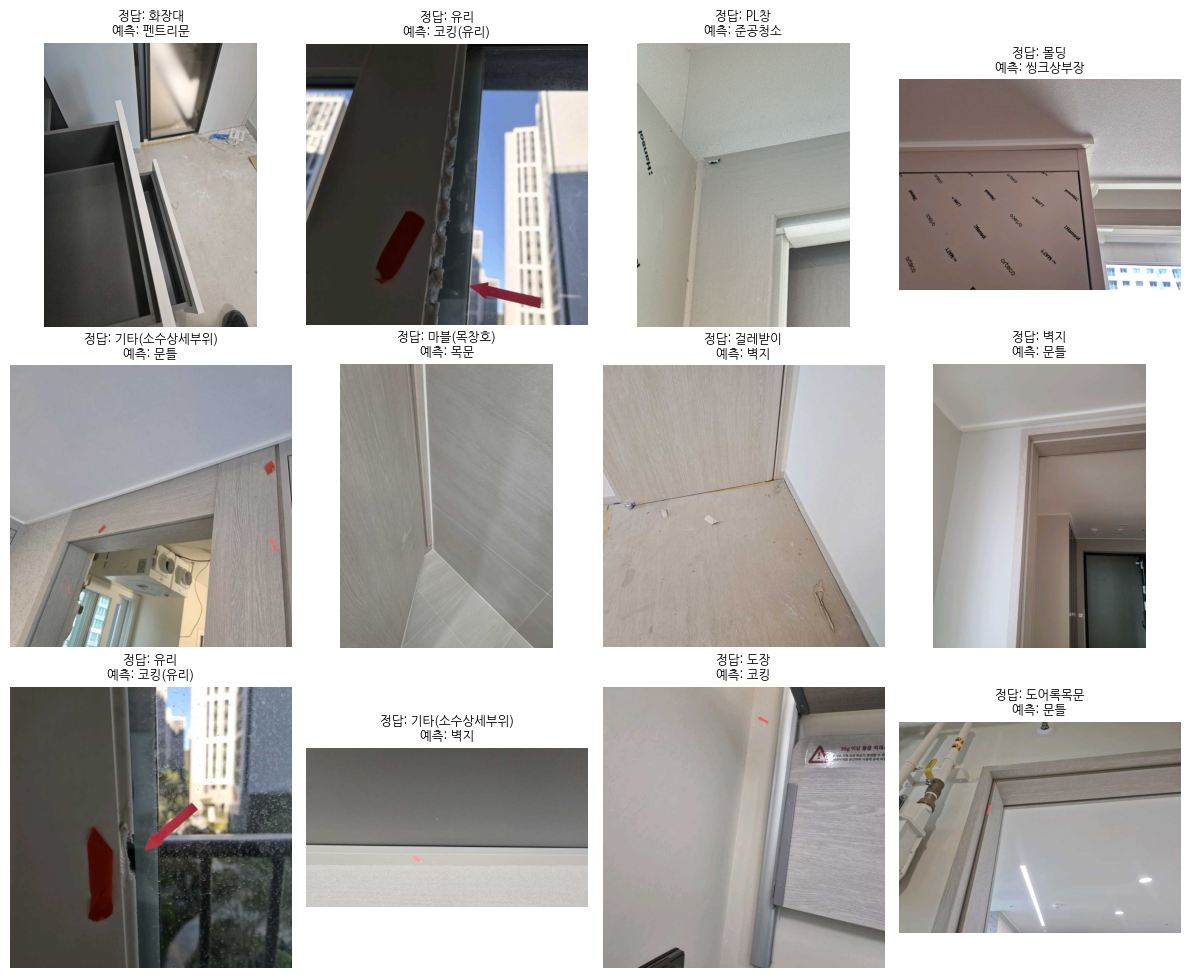


가장 자주 혼동되는 정답->예측 쌍 (상위 10개):
  코킹 -> 도장 : 114건
  도장 -> 코킹 : 84건
  준공청소 -> 벽지 : 42건
  천정지 -> 벽지 : 41건
  PL창 -> 벽지 : 37건
  준공청소 -> 도장 : 31건
  준공청소 -> PL창 : 29건
  유리 -> 코킹(유리) : 28건
  코킹 -> 타일 : 27건
  PL창 -> 준공청소 : 27건


In [16]:
import random
from collections import Counter
from PIL import Image

N_SAMPLES = 12
val_df = splits["validation"].reset_index(drop=True)
mis_idx = np.where(val_y != val_pred)[0]
print(f"검증셋 오분류: {len(mis_idx)} / {len(val_y)}장 ({len(mis_idx) / len(val_y) * 100:.1f}%)")

if len(mis_idx) == 0:
    print("검증셋에서 오분류된 이미지가 없습니다.")
else:
    # 이미지가 일부 손상/누락되어 있어도 전체 셀이 죽지 않도록, 표시 가능한 장수를
    # 채울 때까지 후보를 넉넉히 뽑아서 하나씩 시도합니다.
    candidates = list(mis_idx)
    random.shuffle(candidates)
    shown = []
    load_fail = 0
    for idx in candidates:
        if len(shown) >= N_SAMPLES:
            break
        row = val_df.iloc[idx]
        try:
            img = Image.open(row["image_path"]).convert("RGB")
        except Exception as e:
            load_fail += 1
            print(f"  [건너뜀] 이미지 로드 실패: {row['image_path']} ({e})")
            continue
        shown.append((idx, img))

    if load_fail:
        print(f"({load_fail}장은 이미지 로드에 실패하여 건너뛰었습니다)")

    if not shown:
        print("표시할 수 있는 오분류 이미지가 없습니다 (전부 로드 실패).")
    else:
        cols = 4
        rows = int(np.ceil(len(shown) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.3))
        axes = np.array(axes).reshape(-1)
        for ax, (idx, img) in zip(axes, shown):
            ax.imshow(img)
            ax.set_title(f"정답: {classes[val_y[idx]]}\n예측: {classes[val_pred[idx]]}", fontsize=9)
            ax.axis("off")
        for ax in axes[len(shown):]:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    # 어떤 클래스 쌍이 가장 자주 혼동되는지 집계 (이미지 로드와 무관하게 라벨 기준이라 항상 계산 가능)
    confuse_pairs = Counter()
    for i in mis_idx:
        confuse_pairs[(classes[val_y[i]], classes[val_pred[i]])] += 1
    print("\n가장 자주 혼동되는 정답->예측 쌍 (상위 10개):")
    for (true_c, pred_c), cnt in confuse_pairs.most_common(10):
        print(f"  {true_c} -> {pred_c} : {cnt}건")


## 단일 이미지 추론 (실제 적용 시 사용)

새 사진 한 장을 넣으면 상세부위별 확률을 반환하는 함수입니다. 서버/앱에 연동할 때
이 로직을 그대로 옮기면 됩니다.


In [17]:
from PIL import Image


def predict_image(image_path, model=eval_model, tta=USE_TTA):
    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"이미지를 열 수 없습니다: {image_path} ({e})")
        return []

    try:
        x = eval_tf(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            with torch.autocast(device_type=AMP_DEVICE_TYPE, enabled=USE_AMP):
                logits = model(x).softmax(1)
                if tta:
                    logits = (logits + model(torch.flip(x, dims=[3])).softmax(1)) / 2
        probs = logits.float().cpu().numpy()[0]
        order = probs.argsort()[::-1]
        return [(classes[i], float(probs[i])) for i in order]
    except Exception as e:
        print(f"추론 중 오류가 발생했습니다: {image_path} ({e})")
        return []


# 사용 예:
# for label, prob in predict_image("/content/새사진.jpg")[:3]:
#     print(f"{label}: {prob:.1%}")
